In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import numpy as np
from IPython.display import display

df1 = pd.read_csv('bigmerge_cleaned2.csv')
realTs = df1[df1['spectral_temperature'] > 0].copy()
master = df1[(df1['fit_points'] > 99) & (df1['spectral_temperature'] > 0) & (df1['gain'] > 9.9)& (df1['gain'] < 10.1)].copy()
#display(df1)
#display(realTs)
#display(master)


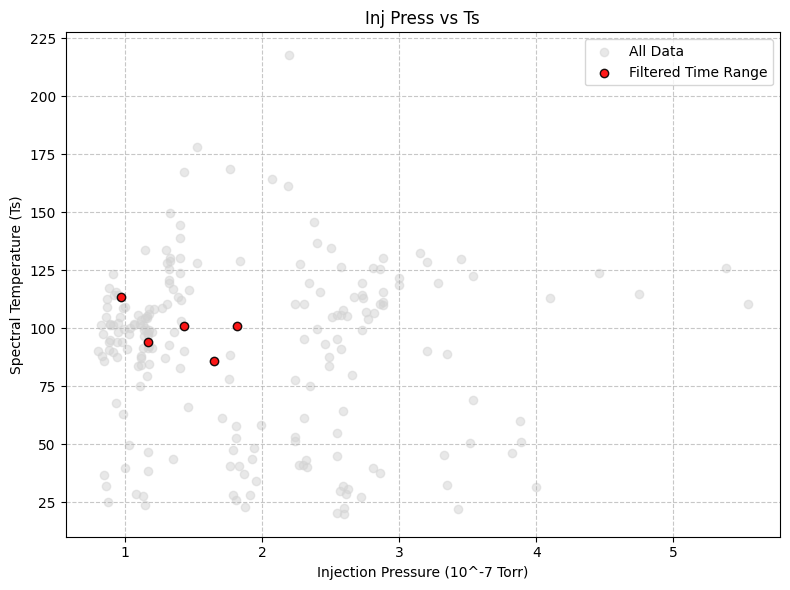

Plot successfully generated with 5 highlighted points.


In [163]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-05-20 03:20:00')
end_time = pd.to_datetime('2025-05-20 03:50:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Inj Pres (-7)']).copy()

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # PLOT 1 (BACKGROUND): All Data
    # Plotted first with a low zorder, 'lightgray' color, and lower alpha (transparency) so it doesn't overwhelm the foreground
    plt.scatter(realTs['Inj Pres (-7)'], realTs['spectral_temperature'], 
                color='lightgray', alpha=0.5, label='All Data', zorder=1)
    
    # PLOT 2 (FOREGROUND): Filtered Time Range
    # Plotted second with a higher zorder and distinct color to make it pop
    plt.scatter(df_plot['Inj Pres (-7)'], df_plot['spectral_temperature'], 
                color='red', edgecolor='k', alpha=0.9, label='Filtered Time Range', zorder=2)
    
    plt.xlabel('Injection Pressure (10^-7 Torr)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Inj Press vs Ts')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend so viewers know what the gray vs red dots mean
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} highlighted points.")
else:
    print("No valid data points found in this time range.")

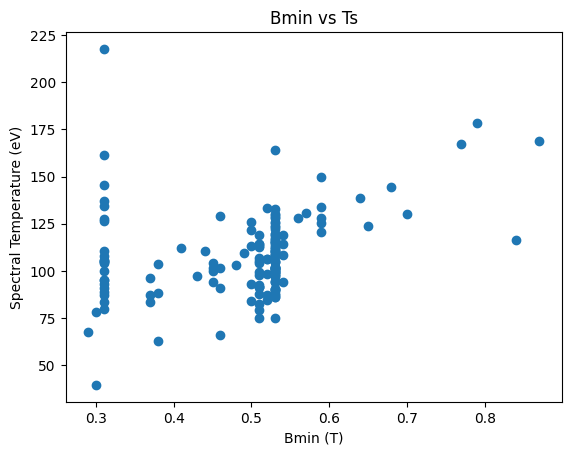

In [94]:
plt.scatter(master['Cent (T)'], master['spectral_temperature'])
plt.xlabel('Bmin (T)')
plt.ylabel('Spectral Temperature (eV)')
#plt.scatter(df['Bmin (Panelview)'], color = 'k', df['Ts'], color = 'red')
plt.title('Bmin vs Ts')
plt.show()

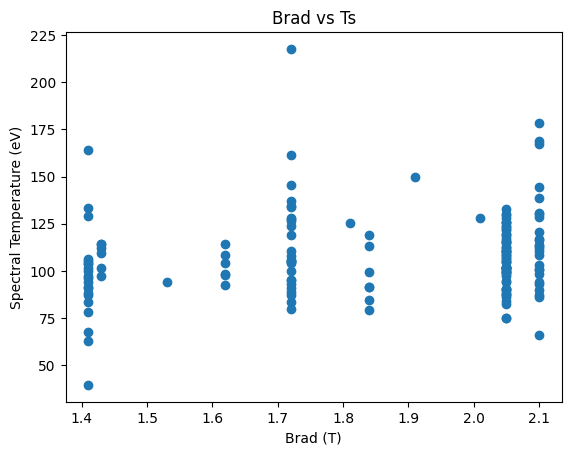

In [98]:
plt.scatter(master['Sext (T)'], master['spectral_temperature'])
plt.xlabel('Brad (T)')
plt.ylabel('Spectral Temperature (eV)')
plt.title('Brad vs Ts')
plt.show()

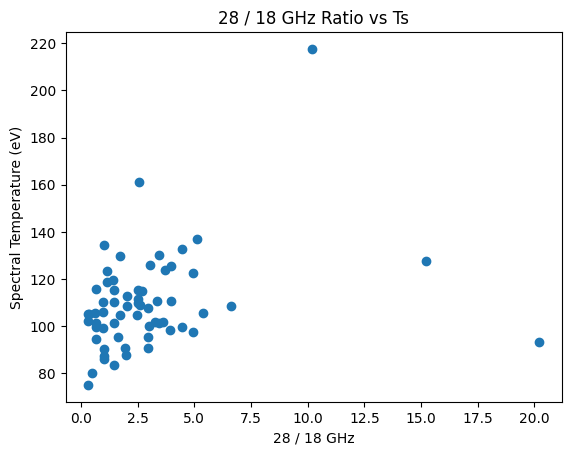

In [100]:
plt.scatter(master['28 GHz'] / master['18 GHz'], master['spectral_temperature'])
plt.xlabel('28 / 18 GHz')
plt.ylabel('Spectral Temperature (eV)')
plt.title('28 / 18 GHz Ratio vs Ts')
plt.show()

Ts vs Brad / Bext =  positive correlation (kind of)

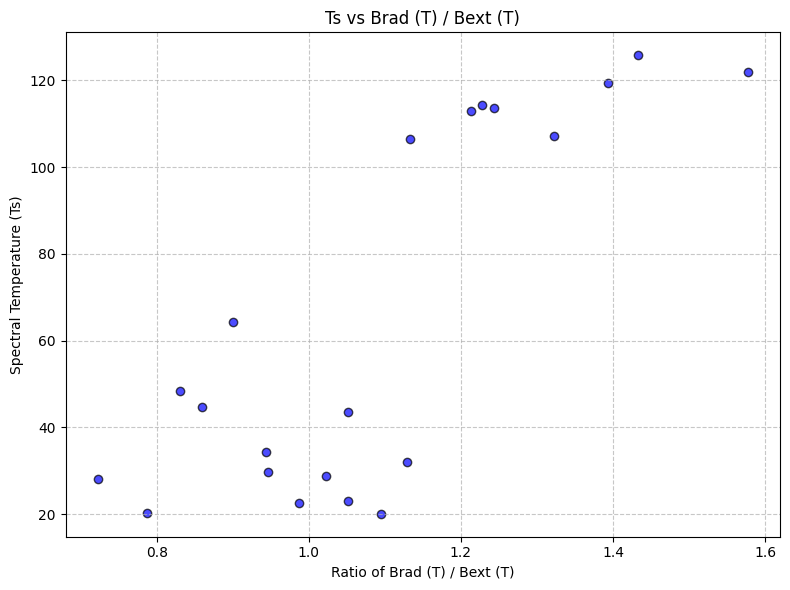

Plot successfully generated with 21 points.


In [120]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-10-14 15:00:00')
end_time = pd.to_datetime('2025-10-15 12:00:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Sext (T)', 'Extr (T)'])

# 3. Prevent division-by-zero errors in case Extr (T) is exactly 0
df_plot = df_plot[df_plot['Extr (T)'] != 0]

# 4. Calculate the ratio
df_plot['Sext_Extr_Ratio'] = df_plot['Sext (T)'] / df_plot['Extr (T)']

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_plot['Sext_Extr_Ratio'], df_plot['spectral_temperature'], 
                c='blue', alpha=0.7, edgecolor='k')
    
    plt.xlabel('Ratio of Brad (T) / Bext (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Brad (T) / Bext (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found in this time range.")

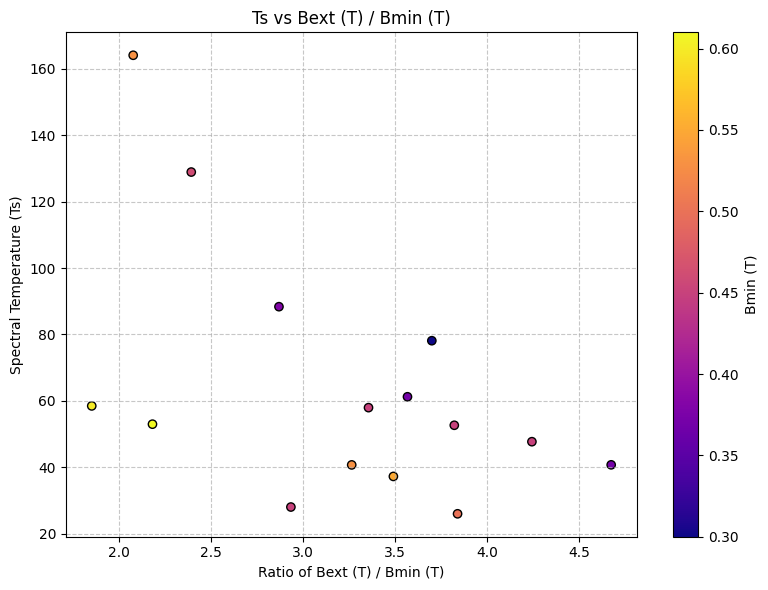

Plot successfully generated with 15 points.


In [136]:
# Ensure the datetime column is properly formatted
realTs['datetime'] = pd.to_datetime(realTs['datetime'])

# Define your strict time boundaries
start_time = pd.to_datetime('2025-10-15 12:00:00')
end_time = pd.to_datetime('2025-10-15 16:10:00')

# 1. Filter by the specified date and time window
df_filtered = realTs[(realTs['datetime'] >= start_time) & (realTs['datetime'] <= end_time)]

# 2. Drop rows missing the required data for this specific plot
# Added .copy() to avoid SettingWithCopyWarning
df_plot = df_filtered.dropna(subset=['spectral_temperature', 'Extr (T)', 'Cent (T)']).copy()

# 3. Prevent division-by-zero errors in case Cent (T) is exactly 0
df_plot = df_plot[df_plot['Cent (T)'] != 0]

# 4. Calculate the ratio
df_plot['Extr_Cent_Ratio'] = df_plot['Extr (T)'] / df_plot['Cent (T)']

# 5. Generate the Plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # UPDATE: Set 'c' to the column data, add a colormap, and assign to a variable 'sc'
    sc = plt.scatter(df_plot['Extr_Cent_Ratio'], df_plot['spectral_temperature'], 
                     c=df_plot['Cent (T)'], cmap='plasma', edgecolor='k')
    
    plt.xlabel('Ratio of Bext (T) / Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bext (T) / Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # UPDATE: Add a colorbar to display the Bmin (T) scale
    plt.colorbar(sc, label='Bmin (T)')
    
    plt.tight_layout()
    plt.show()
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found in this time range.")

Data points matching 28 only criteria: 54


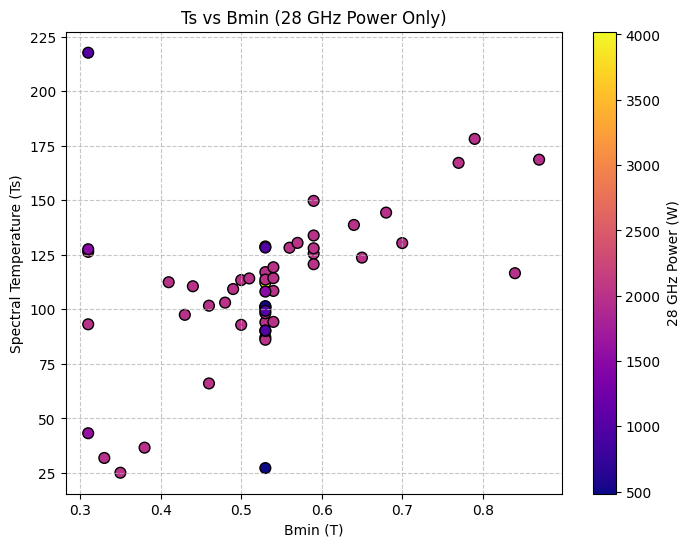

In [155]:
# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 28 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].isna() | (df_plot['18 GHz'] < 100)
cond_28 = df_plot['28 GHz'].notna() & (df_plot['28 GHz'] >= 100)

df_28only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 28 only criteria: {len(df_28only)}")

# 3. Generate the Plot
if len(df_28only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_28only['Cent (T)'], df_28only['spectral_temperature'], 
                     c=df_28only['28 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (28 GHz Power Only)')
    plt.colorbar(sc, label='28 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 28 GHz was the ONLY active power source.")

In [157]:
# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 18 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].notna() | (df_plot['18 GHz'] >= 100)
cond_28 = df_plot['28 GHz'].isna() & (df_plot['28 GHz'] < 100)

df_18only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 18 only criteria: {len(df_18only)}")

# 3. Generate the Plot
if len(df_18only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_18only['Cent (T)'], df_18only['spectral_temperature'], 
                     c=df_18only['18 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (18 GHz Power Only)')
    plt.colorbar(sc, label='18 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 18 GHz was the ONLY active power source.")

Data points matching 18 only criteria: 0
No rows found where 18 GHz was the ONLY active power source.


In [158]:
# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = realTs.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 14 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].notna() | (df_plot['14 GHz'] >= 100)
cond_18 = df_plot['18 GHz'].isna() | (df_plot['18 GHz'] < 100)
cond_28 = df_plot['28 GHz'].isna() & (df_plot['28 GHz'] < 100)

df_14only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching 14 only criteria: {len(df_14only)}")

# 3. Generate the Plot
if len(df_14only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_14only['Cent (T)'], df_14only['spectral_temperature'], 
                     c=df_14only['14 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (14 GHz Power Only)')
    plt.colorbar(sc, label='14 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 14 GHz was the ONLY active power source.")

Data points matching 14 only criteria: 0
No rows found where 14 GHz was the ONLY active power source.


In [106]:
# Drop any rows where we don't have Spectral Temperature or Bmin
df_plot = master.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 2. Filter for ONLY 18 GHz active (assuming >100W means active)
cond_14 = df_plot['14 GHz'].isna() | (df_plot['14 GHz'] < 100)
cond_18 = df_plot['18 GHz'].notna() | (df_plot['18 GHz'] >= 100)
cond_28 = df_plot['28 GHz'].isna() & (df_plot['28 GHz'] < 100)

df_18only = df_plot[cond_14 & cond_18 & cond_28]

print(f"Data points matching criteria: {len(df_18only)}")

# 3. Generate the Plot
if len(df_18only) > 0:
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(df_18only['Cent (T)'], df_18only['spectral_temperature'], 
                     c=df_18only['18 GHz'], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title('Ts vs Bmin (18 GHz Power Only)')
    plt.colorbar(sc, label='18 GHz Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)

else:
    print("No rows found where 18 GHz was the ONLY active power source.")


Data points matching criteria: 0
No rows found where 18 GHz was the ONLY active power source.


Total valid Bmin/Ts rows available: 158



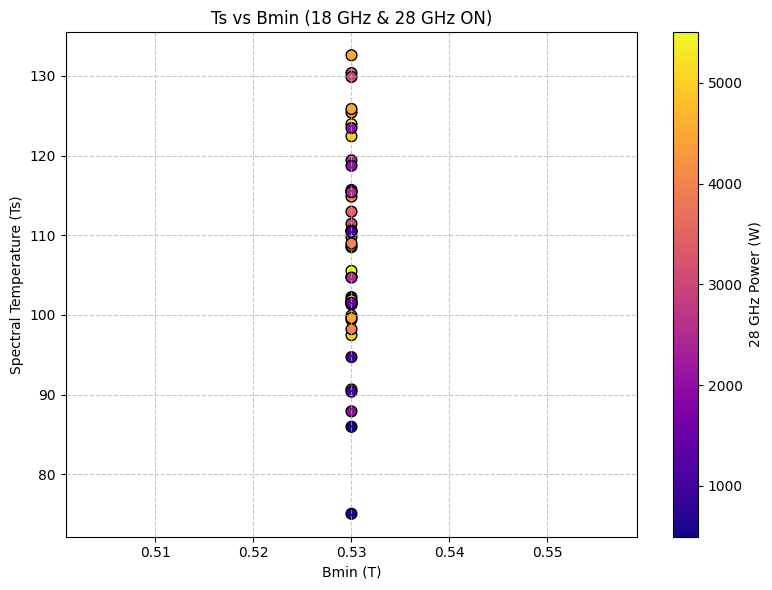

Plotted 'Ts vs Bmin (18 GHz & 28 GHz ON)' with 43 points.


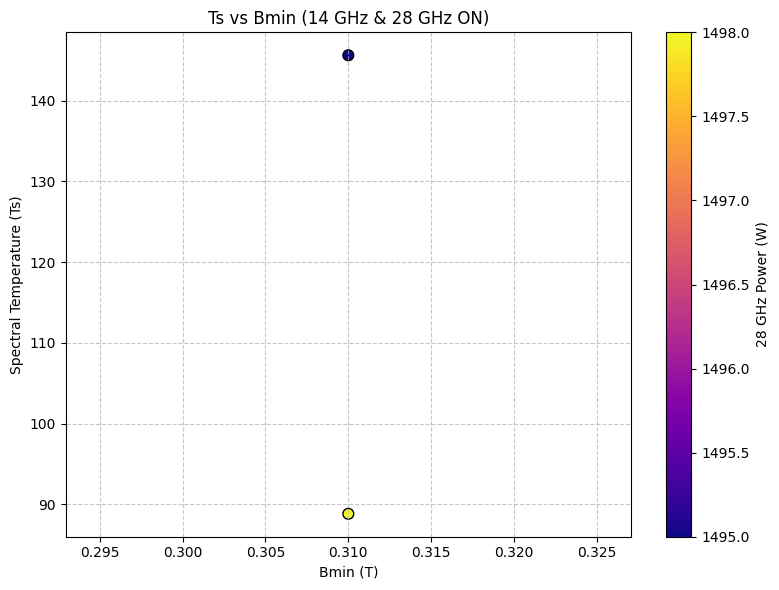

Plotted 'Ts vs Bmin (14 GHz & 28 GHz ON)' with 2 points.


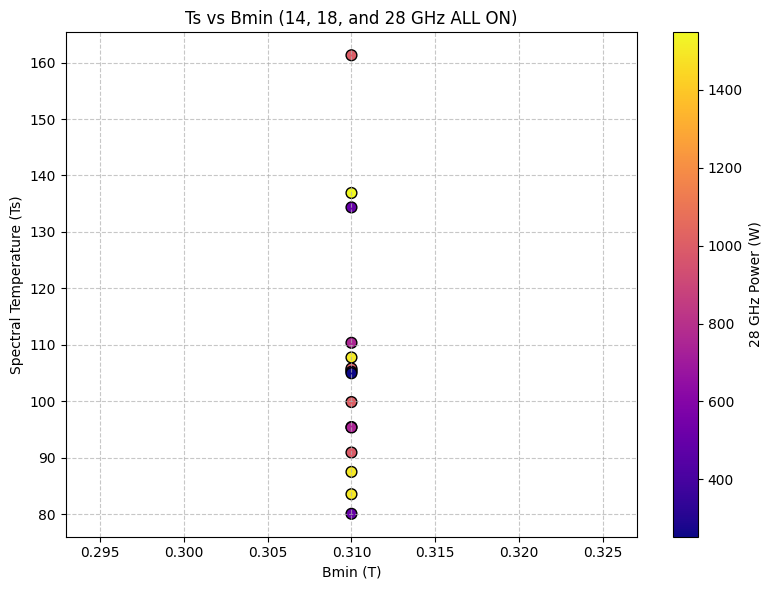

Plotted 'Ts vs Bmin (14, 18, and 28 GHz ALL ON)' with 16 points.


In [107]:
# Drop rows missing Spectral Temperature or Bmin
df_plot = master.dropna(subset=['spectral_temperature', 'Cent (T)'])

# 3. Define the ON/OFF conditions (using 100 W as the active threshold)
c14_on  = df_plot['14 GHz'].notna() & (df_plot['14 GHz'] >= 100)
c14_off = df_plot['14 GHz'].isna()  | (df_plot['14 GHz'] < 100)

c18_on  = df_plot['18 GHz'].notna() & (df_plot['18 GHz'] >= 100)
c18_off = df_plot['18 GHz'].isna()  | (df_plot['18 GHz'] < 100)

c28_on  = df_plot['28 GHz'].notna() & (df_plot['28 GHz'] >= 100)
c28_off = df_plot['28 GHz'].isna()  | (df_plot['28 GHz'] < 100)

# 4. Create the three specific datasets
df_18_and_28 = df_plot[c14_off & c18_on & c28_on]
df_14_and_28 = df_plot[c14_on & c18_off & c28_on]
df_all_three = df_plot[c14_on & c18_on & c28_on]

# 5. Define a helper function to create consistent plots
def plot_ts_vs_bmin(data, title, save_name, color_col):
    if len(data) == 0:
        print(f"Skipping '{title}': 0 data points match these criteria.")
        return
    
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(data['Cent (T)'], data['spectral_temperature'], 
                     c=data[color_col], cmap='plasma', s=60, edgecolor='k')
    
    plt.xlabel('Bmin (T)')
    plt.ylabel('Spectral Temperature (Ts)')
    plt.title(title)
    plt.colorbar(sc, label=f'{color_col} Power (W)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    print(f"Plotted '{title}' with {len(data)} points.")

# 6. Generate the plots!
print(f"Total valid Bmin/Ts rows available: {len(df_plot)}\n")

plot_ts_vs_bmin(
    data=df_18_and_28, 
    title='Ts vs Bmin (18 GHz & 28 GHz ON)', 
    save_name='ts_vs_bmin_18_and_28.png', 
    color_col='28 GHz' # Coloring by 28 GHz power to see its relative contribution
)

plot_ts_vs_bmin(
    data=df_14_and_28, 
    title='Ts vs Bmin (14 GHz & 28 GHz ON)', 
    save_name='ts_vs_bmin_14_and_28.png', 
    color_col='28 GHz'
)

plot_ts_vs_bmin(
    data=df_all_three, 
    title='Ts vs Bmin (14, 18, and 28 GHz ALL ON)', 
    save_name='ts_vs_bmin_all_three.png', 
    color_col='28 GHz'
)

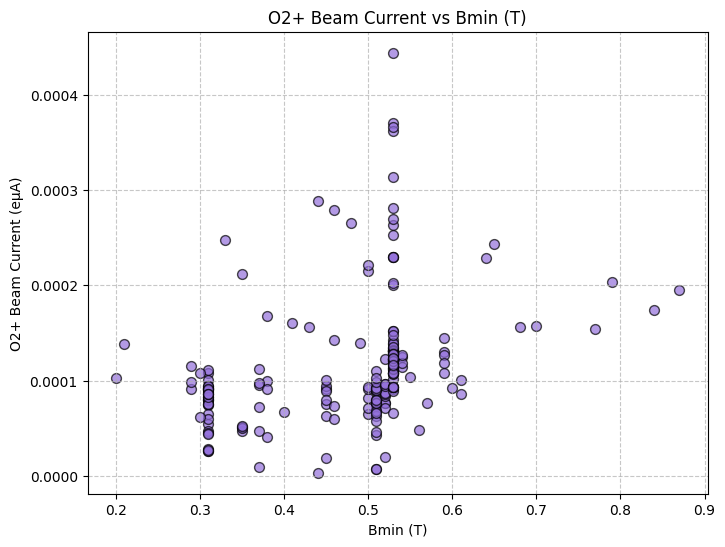

Plot successfully generated with 213 points.


In [146]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O2+_beam_current'

# Drop rows that are missing data for either Cent (T) or O2+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O2+ Beam Current (eμA)')
    plt.title('O2+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O2+ and Bmin (T).")

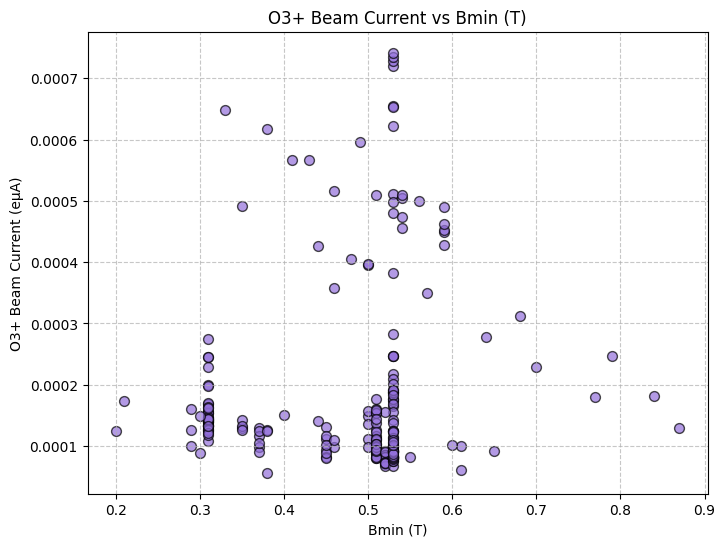

Plot successfully generated with 213 points.


In [147]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O3+_beam_current'

# Drop rows that are missing data for either Cent (T) or O3+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O3+ Beam Current (eμA)')
    plt.title('O3+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O3+ and Bmin (T).")

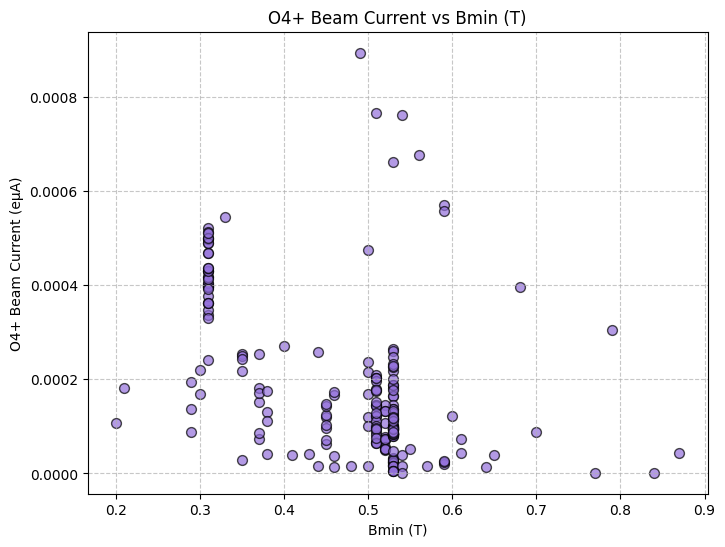

Plot successfully generated with 213 points.


In [148]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O4+_beam_current'

# Drop rows that are missing data for either Cent (T) or O4+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O4+ Beam Current (eμA)')
    plt.title('O4+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O4+ and Bmin (T).")

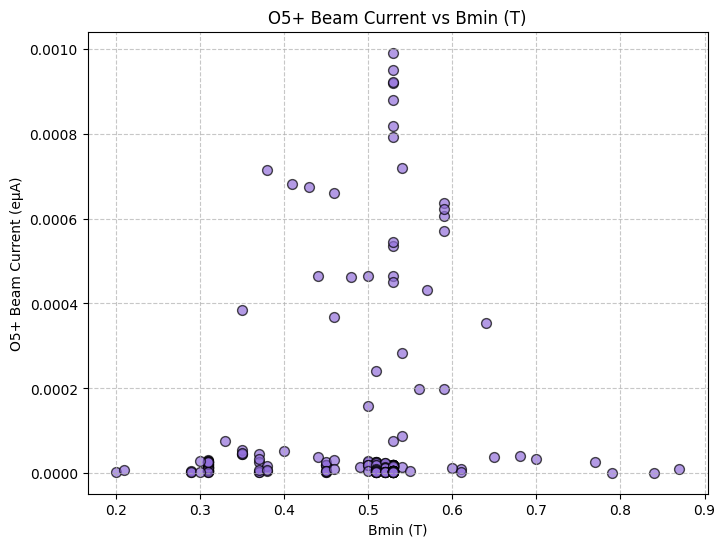

Plot successfully generated with 213 points.


In [149]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O5+_beam_current'

# Drop rows that are missing data for either Cent (T) or O5+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O5+ Beam Current (eμA)')
    plt.title('O5+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O5+ and Bmin (T).")

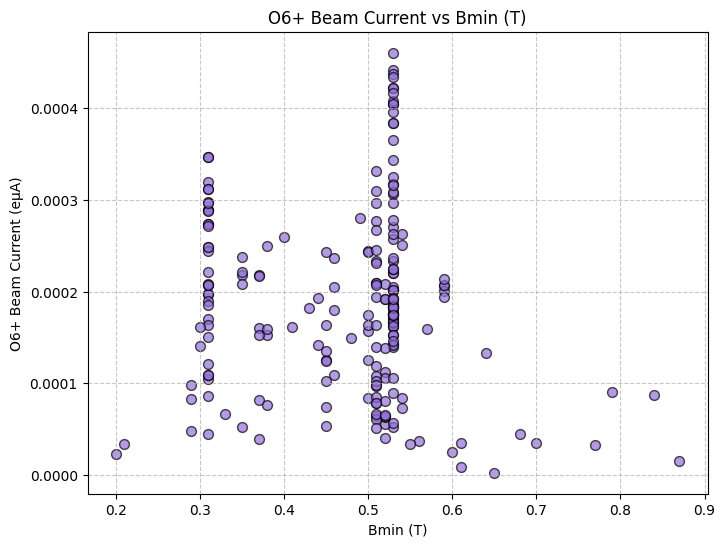

Plot successfully generated with 213 points.


In [150]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O6+_beam_current'

# Drop rows that are missing data for either Cent (T) or O6+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O6+ Beam Current (eμA)')
    plt.title('O6+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O6+ and Bmin (T).")

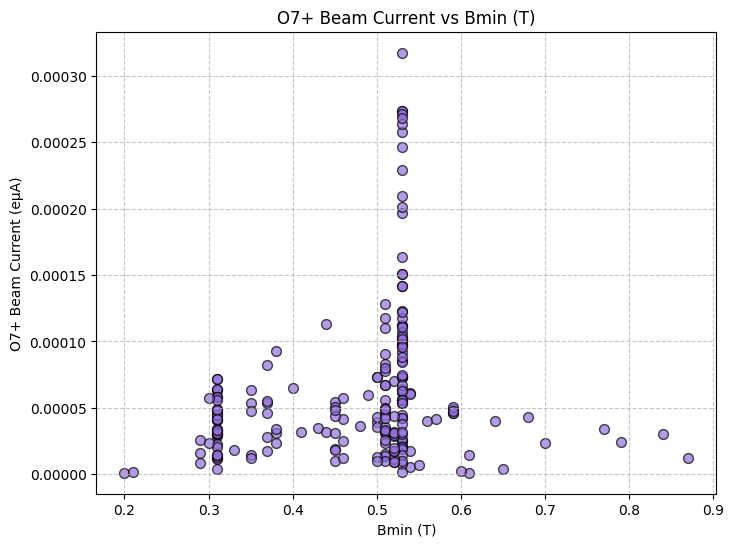

Plot successfully generated with 213 points.


In [151]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O7+_beam_current'

# Drop rows that are missing data for either Cent (T) or O7+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O7+ Beam Current (eμA)')
    plt.title('O7+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O7+ and Bmin (T).")

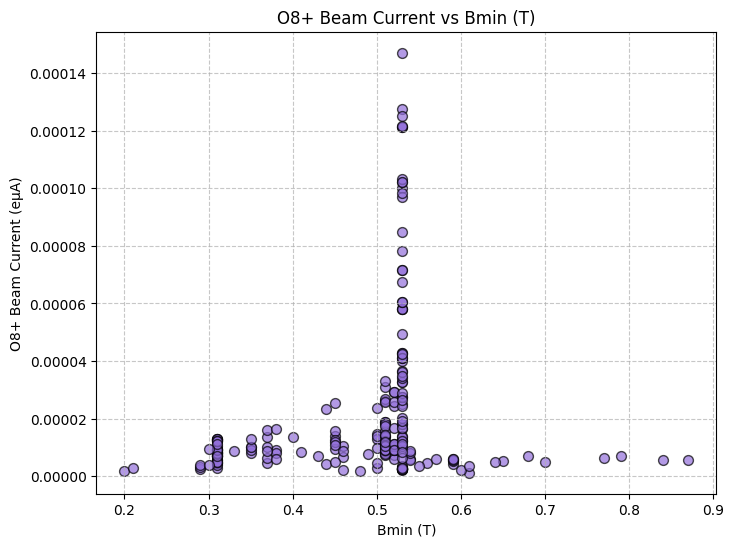

Plot successfully generated with 213 points.


In [152]:
# Define the exact columns you want to plot
x_col = 'Cent (T)'
y_col = 'O8+_beam_current'

# Drop rows that are missing data for either Cent (T) or O8+
df_plot = realTs.dropna(subset=[x_col, y_col]).copy()

# Generate the plot
if len(df_plot) > 0:
    plt.figure(figsize=(8, 6))
    
    # Create the scatter plot
    plt.scatter(df_plot[x_col], df_plot[y_col], 
                color='mediumpurple', alpha=0.7, edgecolor='k', s=50)
    
    # Formatting
    plt.xlabel('Bmin (T)')
    plt.ylabel('O8+ Beam Current (eμA)')
    plt.title('O8+ Beam Current vs Bmin (T)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    print(f"Plot successfully generated with {len(df_plot)} points.")
else:
    print("No valid data points found for O8+ and Bmin (T).")